In [108]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import cv2
import os
from google.colab import files
from sklearn.cluster import KMeans  # For comparison

## 1. K-means Implementation from Scratch

In [109]:

class KMeansClustering:
    def __init__(self, k=2, max_iterations=100, tolerance=1e-4):
        """
        Initialize K-means clustering algorithm

        Parameters:
        -----------
        k : int
            Number of clusters
        max_iterations : int
            Maximum number of iterations
        tolerance : float
            Convergence criterion
        """
        self.k = k
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.centroids = None
        self.labels = None

    def initialize_centroids(self, X):
        """
        Initialize centroids randomly

        Parameters:
        -----------
        X : numpy.ndarray
            Input data of shape (n_samples, n_features)

        Returns:
        --------
        centroids : numpy.ndarray
            Initial centroids of shape (k, n_features)
        """
        # Select k random points as initial centroids
        idx = np.random.choice(X.shape[0], self.k, replace=False)
        centroids = X[idx]
        return centroids

    def assign_clusters(self, X, centroids):
        """
        Assign each point to the nearest centroid

        Parameters:
        -----------
        X : numpy.ndarray
            Input data of shape (n_samples, n_features)
        centroids : numpy.ndarray
            Current centroids of shape (k, n_features)

        Returns:
        --------
        labels : numpy.ndarray
            Cluster assignments of shape (n_samples,)
        """
        distances = np.zeros((X.shape[0], self.k))
        for i in range(self.k):
            # Calculate Euclidean distance between each point and centroid
            distances[:, i] = np.sqrt(np.sum((X - centroids[i])**2, axis=1))

        # Assign each point to the closest centroid
        labels = np.argmin(distances, axis=1)
        return labels

    def update_centroids(self, X, labels):
        """
        Update centroids based on current cluster assignments

        Parameters:
        -----------
        X : numpy.ndarray
            Input data of shape (n_samples, n_features)
        labels : numpy.ndarray
            Current cluster assignments of shape (n_samples,)

        Returns:
        --------
        centroids : numpy.ndarray
            Updated centroids of shape (k, n_features)
        """
        centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            # Calculate mean of all points assigned to cluster i
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                centroids[i] = np.mean(cluster_points, axis=0)
        return centroids

    def fit(self, X):
        """
        Fit K-means clustering to data

        Parameters:
        -----------
        X : numpy.ndarray
            Input data of shape (n_samples, n_features)
        """
        # Initialize centroids
        self.centroids = self.initialize_centroids(X)

        # Iterate until convergence or maximum iterations
        for _ in range(self.max_iterations):
            # Assign clusters
            self.labels = self.assign_clusters(X, self.centroids)

            # Update centroids
            new_centroids = self.update_centroids(X, self.labels)

            # Check for convergence
            if np.sum(np.abs(new_centroids - self.centroids)) < self.tolerance:
                break

            self.centroids = new_centroids

    def predict(self, X):
        """
        Predict cluster labels for new data

        Parameters:
        -----------
        X : numpy.ndarray
            Input data of shape (n_samples, n_features)

        Returns:
        --------
        labels : numpy.ndarray
            Predicted cluster labels of shape (n_samples,)
        """
        return self.assign_clusters(X, self.centroids)

## 2. Image Preprocessing Functions

In [110]:

def load_image(path=None):
    """
    Load an image from path or upload

    Parameters:
    -----------
    path : str, optional
        Path to image file

    Returns:
    --------
    img : numpy.ndarray
        Image as numpy array
    """
    if path is None:
        print("Please upload an Ishihara test image:")
        uploaded = files.upload()
        file_name = list(uploaded.keys())[0]
        img = np.array(Image.open(BytesIO(uploaded[file_name])))
    else:
        img = np.array(Image.open(path))

    return img

def preprocess_image(img):
    """
    Preprocess image for K-means clustering

    Parameters:
    -----------
    img : numpy.ndarray
        Input image

    Returns:
    --------
    features : numpy.ndarray
        Flattened feature matrix of shape (n_pixels, n_features)
    img_shape : tuple
        Original image shape
    """
    img_shape = img.shape

    # Convert to LAB color space for better color segmentation
    if len(img.shape) == 3 and img.shape[2] == 3:
        img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    else:
        # If grayscale, convert to RGB and then to LAB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

    # Normalize color values to [0,1] range for better clustering
    img_lab_norm = img_lab.astype(np.float32)
    img_lab_norm[:,:,0] /= 255.0  # L channel
    img_lab_norm[:,:,1] /= 255.0  # A channel
    img_lab_norm[:,:,2] /= 255.0  # B channel

    # Add spatial features (normalized pixel coordinates)
    h, w = img_shape[:2]
    x_coords, y_coords = np.meshgrid(np.arange(w), np.arange(h))
    x_coords = x_coords.flatten() / w
    y_coords = y_coords.flatten() / h

    # Set weight for spatial features (lower values give more importance to color)
    spatial_weight = 0.3
    x_coords *= spatial_weight
    y_coords *= spatial_weight

    # Combine color and spatial features
    color_features = img_lab_norm.reshape(-1, 3)
    features = np.column_stack([color_features, x_coords, y_coords])

    return features, img_shape

## 3. Number Extraction Functions

In [111]:

def extract_number(img, labels, k, img_shape):
    """
    Extract the number from clustered Ishihara image

    Parameters:
    -----------
    img : numpy.ndarray
        Original image
    labels : numpy.ndarray
        Cluster labels from K-means
    k : int
        Number of clusters
    img_shape : tuple
        Original image shape

    Returns:
    --------
    extracted_number : int or None
        Extracted number or None if no number detected
    number_mask : numpy.ndarray
        Binary mask of the extracted number
    """
    # Reshape labels to image size
    segmented_img = labels.reshape(img_shape[:2])

    # Create binary masks for each cluster
    binary_masks = []
    for i in range(k):
        mask = (segmented_img == i).astype(np.uint8) * 255
        binary_masks.append(mask)

    # Apply morphological operations to clean up the masks
    processed_masks = []
    contour_counts = []

    for mask in binary_masks:
        # Apply morphological operations to clean the mask
        kernel = np.ones((3, 3), np.uint8)
        processed = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        processed = cv2.morphologyEx(processed, cv2.MORPH_CLOSE, kernel)

        # Count contours as a feature to help identify the number cluster
        contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_counts.append(len(contours))

        processed_masks.append(processed)

    # Display all cluster masks
    plt.figure(figsize=(15, 8))
    plt.subplot(2, k//2 + 1, 1)
    plt.imshow(img)
    plt.title("Original Image")

    for i, mask in enumerate(processed_masks):
        plt.subplot(2, k//2 + 1, i + 2)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Cluster {i} (Contours: {contour_counts[i]})")

    plt.tight_layout()
    plt.show()

    # Ask the user to identify which cluster contains the number
    print("Please identify which cluster contains the number (0 to", k-1, "):")
    cluster_idx = int(input())

    # Create a final output image similar to the example (green number on black background)
    number_mask = processed_masks[cluster_idx]

    # Create RGB output image (green number on black background)
    output_img = np.zeros((img_shape[0], img_shape[1], 3), dtype=np.uint8)
    output_img[number_mask > 0] = [0, 255, 0]  # Set to green where mask is positive

    # Display the final result
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Ishihara Test Image")

    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.title("Extracted Number")
    plt.tight_layout()
    plt.show()

    return number_mask

## 4. Main Function for Ishihara Test Processing

In [112]:

def process_ishihara_test(img=None, k=5):
    """
    Process Ishihara test image with K-means clustering

    Parameters:
    -----------
    img : numpy.ndarray, optional
        Input image
    k : int
        Number of clusters

    Returns:
    --------
    extracted_number : int
        Extracted number from the image
    output_img : numpy.ndarray
        Image with the extracted number highlighted
    """
    # Load image if not provided
    if img is None:
        img = load_image()

    # Display original image
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title("Original Ishihara Test Image")
    plt.show()

    # Preprocess image
    features, img_shape = preprocess_image(img)

    # Apply K-means clustering
    print("Applying custom K-means clustering...")
    kmeans = KMeansClustering(k=k, max_iterations=100)
    kmeans.fit(features)
    labels = kmeans.labels

    # Extract number from clustered image
    number_mask = extract_number(img, labels, k, img_shape)

    # Create RGB output image (green number on black background)
    output_img = np.zeros((img_shape[0], img_shape[1], 3), dtype=np.uint8)
    output_img[number_mask > 0] = [0, 255, 0]  # Set to green where mask is positive

    return output_img

## Additional functionality for improved number extraction

In [113]:

def evaluate_clusters(img, labels, k, img_shape):
    """
    Evaluate which cluster likely contains the number based on various metrics

    Parameters:
    -----------
    img : numpy.ndarray
        Original image
    labels : numpy.ndarray
        Cluster labels from K-means
    k : int
        Number of clusters
    img_shape : tuple
        Original image shape

    Returns:
    --------
    ranked_clusters : list
        Clusters ranked by likelihood of containing the number
    """
    # Reshape labels to image size
    segmented_img = labels.reshape(img_shape[:2])

    # Metrics for each cluster
    cluster_metrics = []

    for i in range(k):
        # Create binary mask for this cluster
        mask = (segmented_img == i).astype(np.uint8) * 255

        # Apply morphological operations to clean the mask
        kernel = np.ones((3, 3), np.uint8)
        processed = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        processed = cv2.morphologyEx(processed, cv2.MORPH_CLOSE, kernel)

        # Calculate metrics
        # 1. Number of pixels in cluster
        pixel_count = np.sum(processed > 0)

        # 2. Number of contours (dots in Ishihara tests form many small contours)
        contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_count = len(contours)

        # 3. Average size of contours
        avg_contour_size = pixel_count / (contour_count + 1e-5)  # Avoid division by zero

        # 4. Spatial distribution - standard deviation of coordinates
        y_coords, x_coords = np.where(processed > 0)
        if len(y_coords) > 0:
            spatial_std = np.std(y_coords) + np.std(x_coords)
        else:
            spatial_std = 0

        # Store metrics
        cluster_metrics.append({
            'cluster_id': i,
            'pixel_count': pixel_count,
            'contour_count': contour_count,
            'avg_contour_size': avg_contour_size,
            'spatial_std': spatial_std
        })

    # Sort clusters by contour count (high contour count often indicates the number in Ishihara tests)
    ranked_clusters = sorted(cluster_metrics, key=lambda x: x['contour_count'], reverse=True)

    # Print out metrics for each cluster
    print("Cluster metrics (ranked by number of contours):")
    for i, metrics in enumerate(ranked_clusters):
        print(f"Rank {i+1}: Cluster {metrics['cluster_id']} - " +
              f"Contours: {metrics['contour_count']}, " +
              f"Pixels: {metrics['pixel_count']}, " +
              f"Avg Contour Size: {metrics['avg_contour_size']:.2f}, " +
              f"Spatial Std: {metrics['spatial_std']:.2f}")

    return ranked_clusters

## upload image and print output

This script will help you extract numbers from Ishihara test images.
Please upload your Ishihara test image when prompted.
Please upload an Ishihara test image:


Saving 74.jpg to 74 (5).jpg
Using 20 clusters for K-means. This works well for most Ishihara test images.


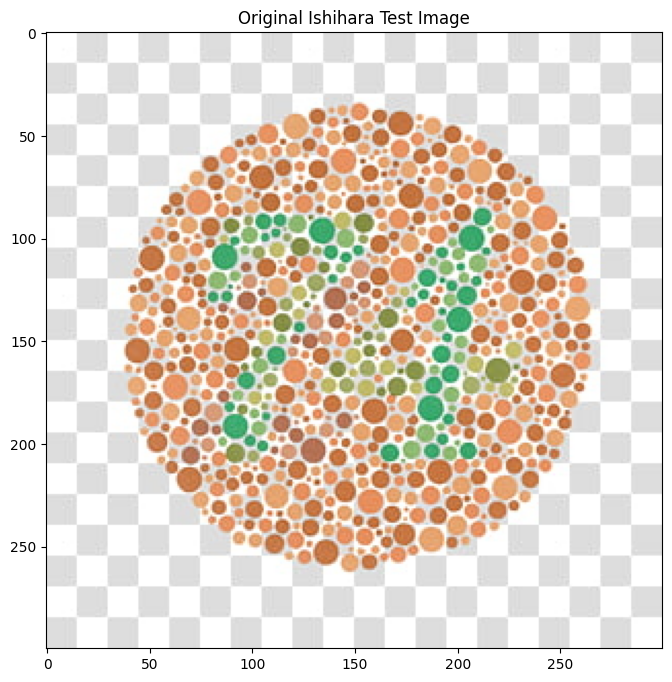

Applying custom K-means clustering...


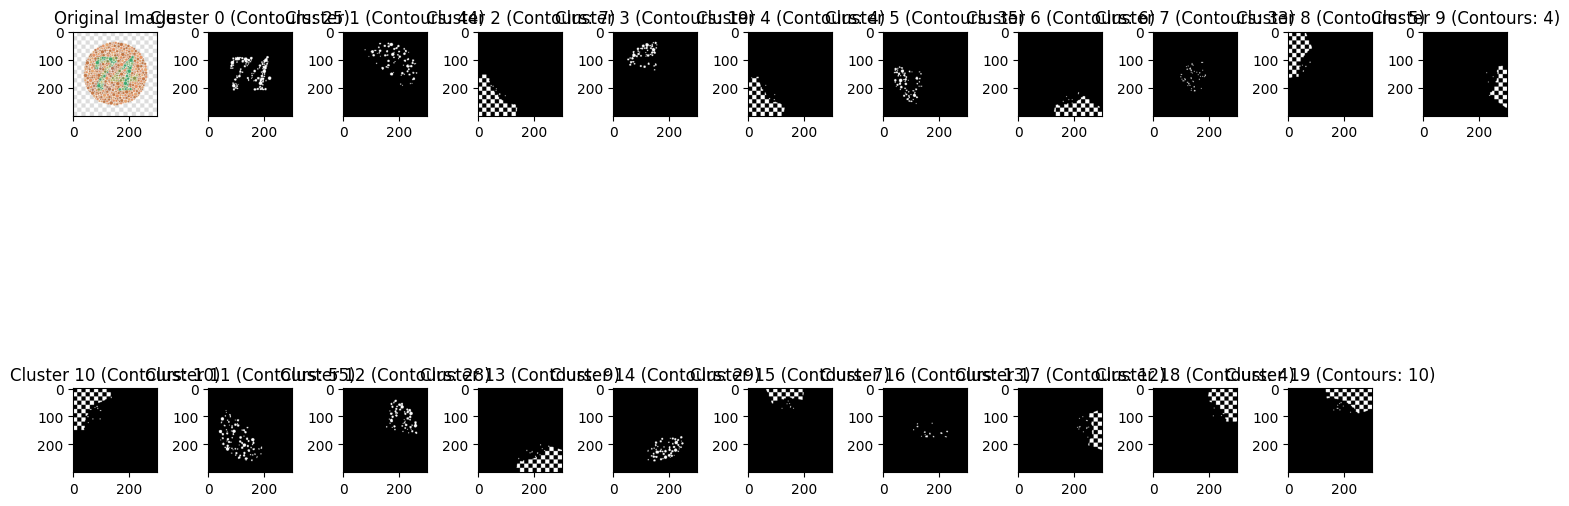

Please identify which cluster contains the number (0 to 19 ):
0


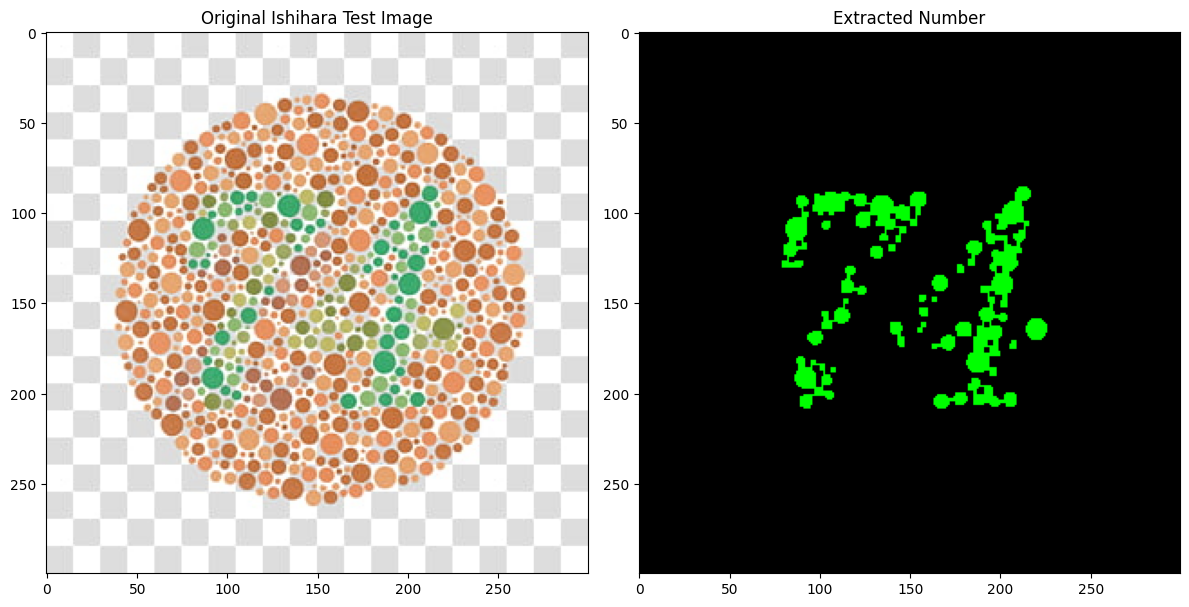

In [120]:

if __name__ == "__main__":
    print("This script will help you extract numbers from Ishihara test images.")
    print("Please upload your Ishihara test image when prompted.")

    # Let user upload their own image
    img = load_image()

    # Suggest a reasonable k value
    k = 20

    print(f"Using {k} clusters for K-means. This works well for most Ishihara test images.")

    # Process the image
    extracted_number= process_ishihara_test(img, k=k)